In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv("Clean_healthcare_dataset.csv")
df.head()


,Name,Age,Gender,Blood _Type,Medical_Condition,Date_of_Admission,Doctor,Hospital,Insurance_Provider,Billing_Amount,Room_Number,Admission_Type,Discharge_Date,Medication,Test_Results,Length_of_Stay
0,Bobby JacksOn,30,Male,B-,Cancer,31-01-2024,Matthew Smith,Sons and Miller,Blue Cross,18856.28,328,Urgent,02-02-2024,Paracetamol,Normal,2
1,LesLie TErRy,62,Male,A+,Obesity,20-08-2019,Samantha Davies,Kim Inc,Medicare,33643.33,265,Emergency,26-08-2019,Ibuprofen,Inconclusive,6
2,DaNnY sMitH,76,Female,A-,Obesity,22-09-2022,Tiffany Mitchell,Cook PLC,Aetna,27955.10,205,Emergency,07-10-2022,Aspirin,Normal,15
3,andrEw waTtS,28,Female,O+,Diabetes,18-11-2020,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.78,450,Elective,18-12-2020,Ibuprofen,Abnormal,30
4,adrIENNE bEll,43,Female,AB+,Cancer,19-09-2022,Kathleen Hanna,White-White,Aetna,14238.32,458,Urgent,09-10-2022,Penicillin,Abnormal,20


In [3]:
df.shape

(54966, 16)

In [4]:
df.describe()

,Age,Billing_Amount,Room_Number,Length_of_Stay
count,54966.000000,54966.000000,54966.000000,54966.000000
mean,51.535185,25544.306260,301.124404,15.499290
std,19.605661,14208.409715,115.223143,8.661471
min,13.000000,-2008.490000,101.000000,1.000000
25%,35.000000,13243.722500,202.000000,8.000000
50%,52.000000,25542.750000,302.000000,15.000000
75%,68.000000,37819.857500,401.000000,23.000000
max,89.000000,52764.280000,500.000000,30.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 54966 entries, 0 to 54965
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                54966 non-null  str    
 1   Age                 54966 non-null  int64  
 2   Gender              54966 non-null  str    
 3   Blood _Type         54966 non-null  str    
 4   Medical_Condition   54966 non-null  str    
 5   Date_of_Admission   54966 non-null  str    
 6   Doctor              54966 non-null  str    
 7   Hospital            54966 non-null  str    
 8   Insurance_Provider  54966 non-null  str    
 9   Billing_Amount      54966 non-null  float64
 10  Room_Number         54966 non-null  int64  
 11  Admission_Type      54966 non-null  str    
 12  Discharge_Date      54966 non-null  str    
 13  Medication          54966 non-null  str    
 14  Test_Results        54966 non-null  str    
 15  Length_of_Stay      54966 non-null  int64  
dtypes: float64(1), 

In [6]:
df.columns

Index(['Name', 'Age', 'Gender', 'Blood _Type', 'Medical_Condition',
       'Date_of_Admission', 'Doctor', 'Hospital', 'Insurance_Provider',
       'Billing_Amount', 'Room_Number', 'Admission_Type', 'Discharge_Date',
       'Medication', 'Test_Results', 'Length_of_Stay'],
      dtype='str')

In [7]:
# missing Vaiues check
df.isna().sum()

Name                  0
Age                   0
Gender                0
Blood _Type           0
Medical_Condition     0
Date_of_Admission     0
Doctor                0
Hospital              0
Insurance_Provider    0
Billing_Amount        0
Room_Number           0
Admission_Type        0
Discharge_Date        0
Medication            0
Test_Results          0
Length_of_Stay        0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
Gender_count=df.groupby('Gender')['Name'].count().sort_values(ascending=False)

Text(0, 0.5, 'Total_patients')

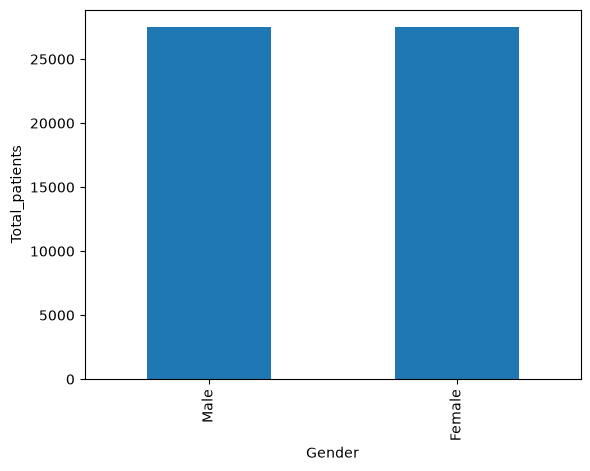

In [80]:
Gender_count.plot(kind='bar')
plt.ylabel("Total_patients")

Text(0.5, 1.0, 'Medical_Condition wise Total Patients')

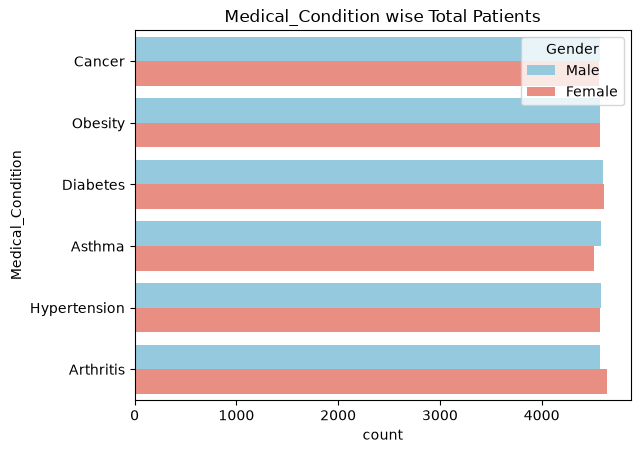

In [10]:

sns.countplot(y=df['Medical_Condition'],hue=df['Gender'],palette=["skyblue","salmon"])

plt.title("Medical_Condition wise Total Patients")



In [26]:
df["Admission_month"]=pd.to_datetime(df["Date_of_Admission"]).dt.month_name()
df.head()

C:\Users\sbads\AppData\Local\Temp\ipykernel_18300\861122468.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Admission_month"]=pd.to_datetime(df["Date_of_Admission"]).dt.month_name()


,Name,Age,Gender,Blood _Type,Medical_Condition,Date_of_Admission,Doctor,Hospital,Insurance_Provider,Billing_Amount,Room_Number,Admission_Type,Discharge_Date,Medication,Test_Results,Length_of_Stay,Admission_month
0,Bobby JacksOn,30,Male,B-,Cancer,31-01-2024,Matthew Smith,Sons and Miller,Blue Cross,18856.28,328,Urgent,02-02-2024,Paracetamol,Normal,2,January
1,LesLie TErRy,62,Male,A+,Obesity,20-08-2019,Samantha Davies,Kim Inc,Medicare,33643.33,265,Emergency,26-08-2019,Ibuprofen,Inconclusive,6,August
2,DaNnY sMitH,76,Female,A-,Obesity,22-09-2022,Tiffany Mitchell,Cook PLC,Aetna,27955.10,205,Emergency,07-10-2022,Aspirin,Normal,15,September
3,andrEw waTtS,28,Female,O+,Diabetes,18-11-2020,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.78,450,Elective,18-12-2020,Ibuprofen,Abnormal,30,November
4,adrIENNE bEll,43,Female,AB+,Cancer,19-09-2022,Kathleen Hanna,White-White,Aetna,14238.32,458,Urgent,09-10-2022,Penicillin,Abnormal,20,September


In [42]:
Trend=df.groupby('Admission_month')['Name'].count().sort_values(ascending=False)

Text(0, 0.5, 'Total_patients')

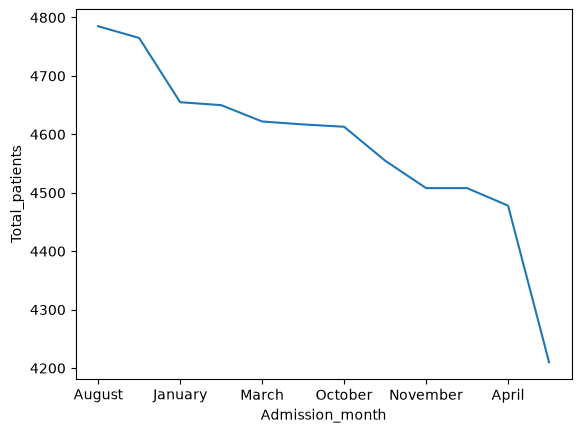

In [43]:
Trend.plot(kind="line")
plt.ylabel("Total_patients")

Text(0, 0.5, 'Patients_Count')

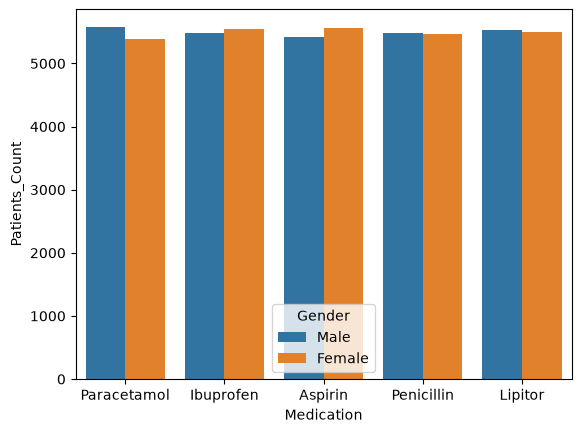

In [62]:
sns.countplot(x=df['Medication'],hue=df['Gender'])
plt.ylabel("Patients_Count")

In [89]:
Bills_amount=df.groupby('Insurance_Provider')['Billing_Amount'].sum()/1000000

Text(0, 0.5, 'Total_Bills(M)')

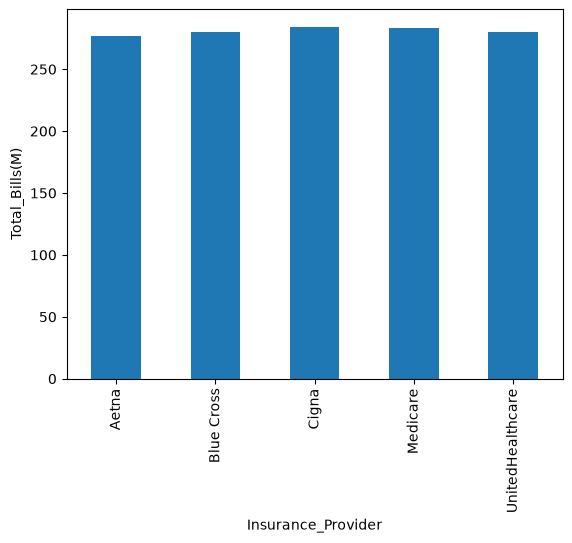

In [91]:
Bills_amount.plot(kind='bar')
plt.ylabel("Total_Bills(M)")


In [101]:
Bills_amount=df.groupby('Admission_Type')['Billing_Amount'].sum()/1000000

Text(0, 0.5, 'Total_bills (M)')

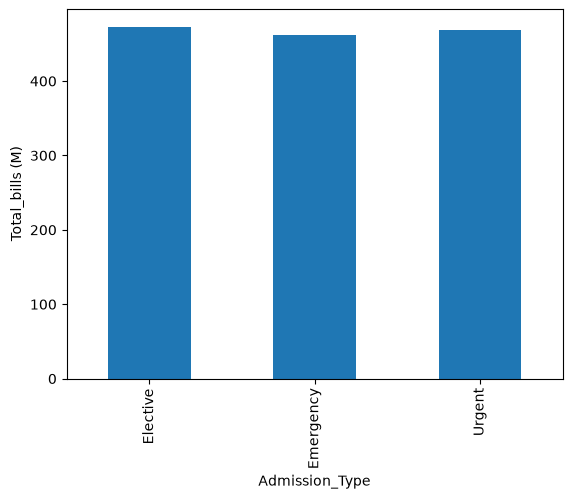

In [102]:
Bills_amount.plot(kind='bar')
plt.ylabel("Total_bills (M)")

Text(0, 0.5, 'Patients_Count (Thousand)')

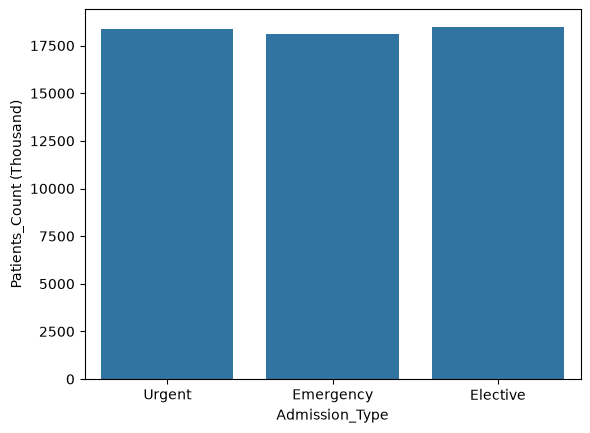

In [103]:
sns.countplot(x=df["Admission_Type"])
plt.ylabel("Patients_Count (Thousand)")

<Axes: xlabel='Medical_Condition', ylabel='Age'>

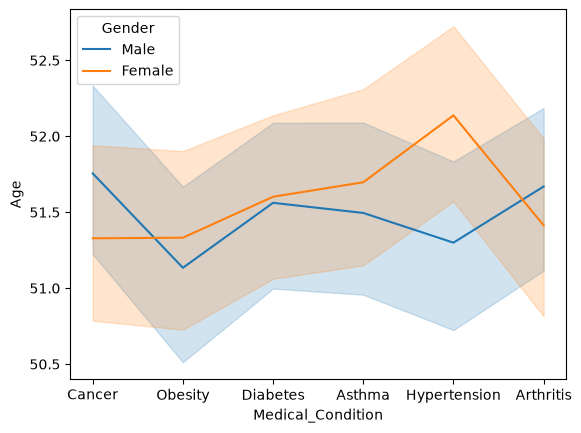

In [107]:
sns.lineplot(x=df['Medical_Condition'],y=df['Age'],hue=df['Gender'])